# 02 · Análise Exploratória — Projeto Vértice (Vértice Retail)

**Objetivo deste notebook:** visualizar as relações entre as métricas das 5 bases e
o problema central do case — **queda de rentabilidade em um negócio que continua
crescendo em volume**. Cada seção corresponde a uma das linhas de investigação
sugeridas no case (Margem, Marketing, Operações, Atendimento, Cliente).

Este notebook consome as bases já tratadas em `01_qualidade_dados.ipynb`
(`data/processed/*.parquet`) e assume as decisões de tratamento documentadas lá —
em particular: **não usar `vendas.customer_id` para segmentação de cliente** (usar
`clientes.csv` isoladamente) e **tratar jan/2023–jan/2024 como a janela primária**
de `vendas.csv` (as demais bases vão até dez/2025).

Os padrões visuais aqui geram as hipóteses que testamos formalmente em
`03_testes_estatisticos.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

%matplotlib inline
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

sns.set_theme(style='whitegrid', context='notebook')
PALETTE = {
    'primary': '#2C6E8F',
    'accent':  '#D9782D',
    'good':    '#3C8A5B',
    'bad':     '#C24A4A',
    'neutral': '#8A8F98',
    'total':   '#0b0b0b',
}
CANAL_ORDER = ['Orgânico', 'Marketplace', 'Google Ads', 'Instagram Ads',
               'TikTok Ads', 'Email Marketing', 'Influenciador']
sns.set_palette('deep')

def fmt_reais(x, pos=None):
    if abs(x) >= 1_000_000:
        return f'R$ {x/1_000_000:.1f}M'
    if abs(x) >= 1_000:
        return f'R$ {x/1_000:.0f}k'
    return f'R$ {x:.0f}'

def fmt_pct(x, pos=None):
    return f'{x*100:.0f}%'

PROC_DIR = Path('..') / 'data' / 'processed'
vendas = pd.read_parquet(PROC_DIR / 'vendas.parquet')
clientes = pd.read_parquet(PROC_DIR / 'clientes.parquet')
estoque = pd.read_parquet(PROC_DIR / 'estoque.parquet')
marketing = pd.read_parquet(PROC_DIR / 'marketing.parquet')
atendimento = pd.read_parquet(PROC_DIR / 'atendimento.parquet')

for name, df in [('vendas', vendas), ('clientes', clientes), ('estoque', estoque),
                  ('marketing', marketing), ('atendimento', atendimento)]:
    print(f"{name:<12} {df.shape}")

vendas       (27758, 23)
clientes     (15000, 15)
estoque      (5000, 18)
marketing    (3500, 15)
atendimento  (35840, 13)


## 1. Panorama geral — receita e margem ao longo do tempo

Primeiro, olhamos a série mensal de receita, margem e margem % dentro da janela
confiável de `vendas.csv` (jan/2023–jan/2024). O objetivo é responder à primeira
pergunta do case: **a empresa cresce, mas a rentabilidade cai?**

In [2]:
monthly = (
    vendas.groupby('ano_mes')
    .agg(
        receita_bruta=('receita_bruta', 'sum'),
        receita_liquida=('receita_liquida', 'sum'),
        margem_contribuicao=('margem_contribuicao', 'sum'),
        pedidos=('order_id', 'nunique'),
    )
    .reset_index()
)
monthly['margem_pct'] = monthly['margem_contribuicao'] / monthly['receita_liquida']
monthly['ticket_medio'] = monthly['receita_liquida'] / monthly['pedidos']
# jan/2023 e jan/2024 são meses parciais (janela de 13 meses corta no meio de jan/24);
# mantemos no gráfico mas destacamos visualmente.
monthly = monthly.sort_values('ano_mes').reset_index(drop=True)
monthly

,ano_mes,receita_bruta,receita_liquida,margem_contribuicao,pedidos,margem_pct,ticket_medio
0,2023-01,1009576.21,936791.00,513733.25,1381,0.548397,678.342505
1,2023-02,987724.54,914035.21,498077.69,1356,0.544922,674.067264
2,2023-03,2435643.05,2244840.33,1223857.95,3144,0.545187,714.007739
3,2023-04,1189527.98,1097874.20,597472.25,1556,0.544208,705.574679
4,2023-05,2584966.54,2396620.61,1309057.93,3560,0.546210,673.208037
5,2023-06,1150096.90,1063703.06,583280.45,1540,0.548349,690.716273
6,2023-07,1151659.51,1059387.88,575814.69,1538,0.543535,688.808765
7,2023-08,1184261.24,1085966.80,589029.24,1627,0.542401,667.465765
8,2023-09,1265119.39,1168927.59,637676.12,1727,0.545522,676.854424
9,2023-10,1273685.16,1167445.05,632490.23,1709,0.541773,683.115886


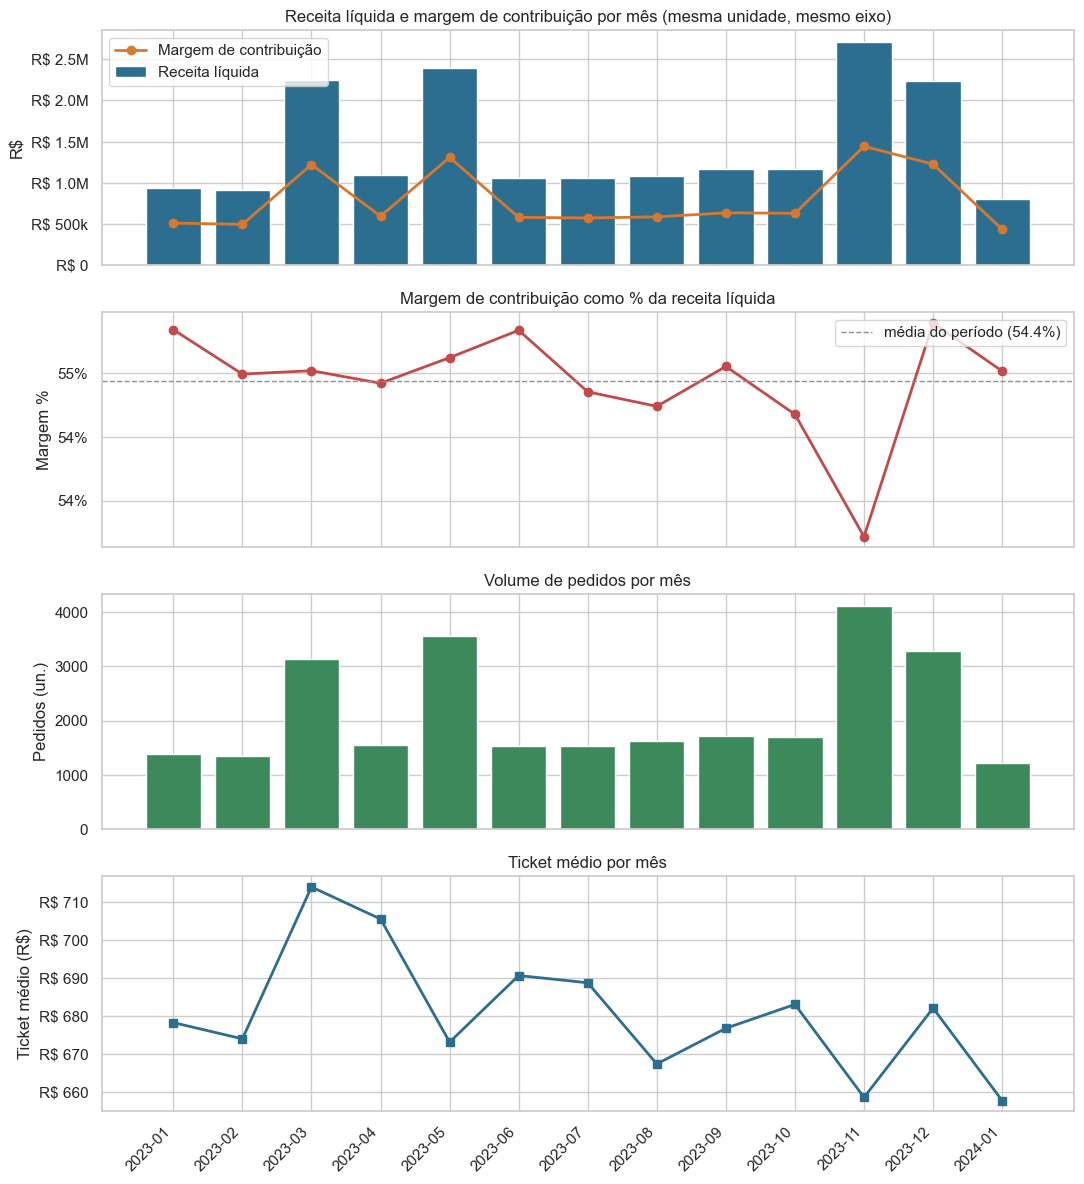

In [3]:
# 4 painéis de eixo único (nunca dois eixos-Y na mesma área de plotagem — um
# gráfico de eixo duplo distorce a leitura visual de correlação entre séries).
fig, axes = plt.subplots(4, 1, figsize=(11, 12), sharex=True)

ax = axes[0]
ax.bar(monthly['ano_mes'], monthly['receita_liquida'], color=PALETTE['primary'], label='Receita líquida')
ax.plot(monthly['ano_mes'], monthly['margem_contribuicao'], color=PALETTE['accent'],
        marker='o', linewidth=2, label='Margem de contribuição')
ax.set_ylabel('R$')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(fmt_reais))
ax.set_title('Receita líquida e margem de contribuição por mês (mesma unidade, mesmo eixo)')
ax.legend(loc='upper left')

ax = axes[1]
ax.plot(monthly['ano_mes'], monthly['margem_pct'], color=PALETTE['bad'], marker='o', linewidth=2)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(fmt_pct))
ax.set_ylabel('Margem %')
ax.set_title('Margem de contribuição como % da receita líquida')
ax.axhline(monthly['margem_pct'].mean(), color=PALETTE['neutral'], linestyle='--', linewidth=1,
           label=f"média do período ({monthly['margem_pct'].mean():.1%})")
ax.legend(loc='upper right')

ax = axes[2]
ax.bar(monthly['ano_mes'], monthly['pedidos'], color=PALETTE['good'])
ax.set_ylabel('Pedidos (un.)')
ax.set_title('Volume de pedidos por mês')

ax = axes[3]
ax.plot(monthly['ano_mes'], monthly['ticket_medio'], color=PALETTE['primary'], marker='s', linewidth=2)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(fmt_reais))
ax.set_ylabel('Ticket médio (R$)')
ax.set_title('Ticket médio por mês')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Leitura:** observe se o volume de pedidos/receita sobe enquanto a margem % cai —
esse é o padrão que confirmaria a hipótese central do case ("a empresa cresce, mas
perde rentabilidade"). Guarde essa leitura visual: ela vira um teste formal de
tendência (regressão/correlação com o tempo) no notebook 03.

## 2. Margem por canal de venda

Onde a margem se deteriora: por canal?

In [4]:
por_canal = (
    vendas.groupby('canal')
    .agg(
        receita_liquida=('receita_liquida', 'sum'),
        margem_contribuicao=('margem_contribuicao', 'sum'),
        pedidos=('order_id', 'nunique'),
        margem_pct_media=('margem_pct', 'mean'),
        desconto_pct_medio=('desconto_pct', 'mean'),
        taxa_devolucao=('devolvido', 'mean'),
    )
    .assign(margem_pct_agregada=lambda d: d['margem_contribuicao'] / d['receita_liquida'])
    .sort_values('receita_liquida', ascending=False)
)
por_canal

,receita_liquida,margem_contribuicao,pedidos,margem_pct_media,desconto_pct_medio,taxa_devolucao,margem_pct_agregada
canal,,,,,,,
Marketplace,3986568.87,2050034.23,6040,0.459734,0.080350,0.149503,0.514235
Google Ads,3642784.40,1997771.23,5504,0.503212,0.084266,0.152435,0.548419
Instagram Ads,3270791.31,1800228.35,4965,0.501825,0.079997,0.150655,0.550395
Orgânico,2137746.01,1179151.85,3246,0.503480,0.078206,0.144177,0.551587
Influenciador,2064752.77,1147084.67,2263,0.524518,0.082980,0.149801,0.555555
TikTok Ads,1895088.40,1044491.96,2928,0.502656,0.081219,0.143443,0.551157
Email Marketing,1891602.25,1051674.36,2812,0.511601,0.072448,0.145804,0.555970


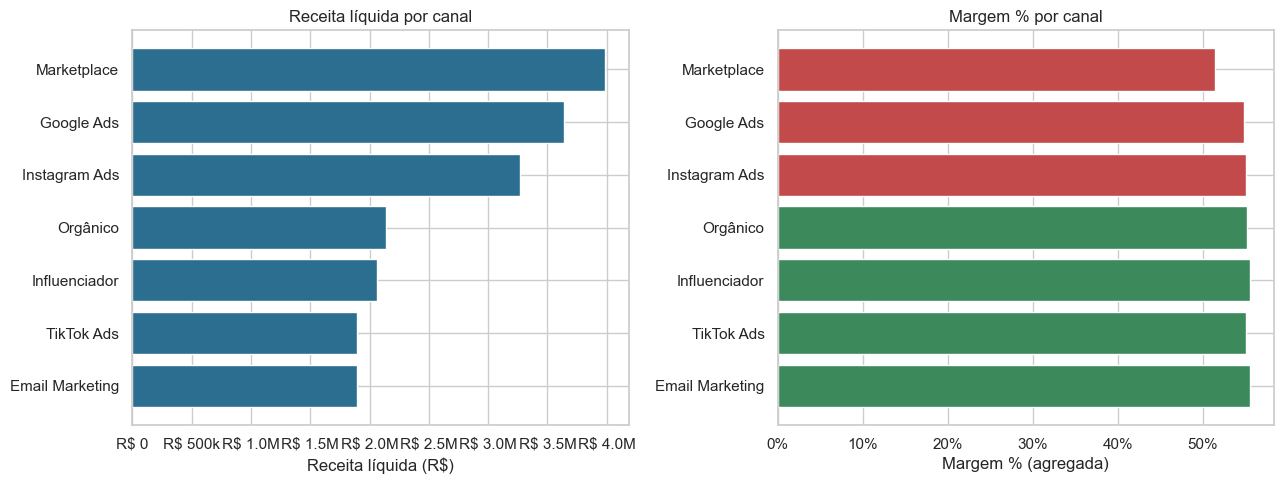

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order = por_canal.index.tolist()
ax = axes[0]
bars = ax.barh(order, por_canal.loc[order, 'receita_liquida'], color=PALETTE['primary'])
ax.set_xlabel('Receita líquida (R$)')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(fmt_reais))
ax.set_title('Receita líquida por canal')
ax.invert_yaxis()

ax = axes[1]
colors = [PALETTE['bad'] if v < por_canal['margem_pct_agregada'].median() else PALETTE['good']
          for v in por_canal.loc[order, 'margem_pct_agregada']]
ax.barh(order, por_canal.loc[order, 'margem_pct_agregada'], color=colors)
ax.set_xlabel('Margem % (agregada)')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(fmt_pct))
ax.set_title('Margem % por canal')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

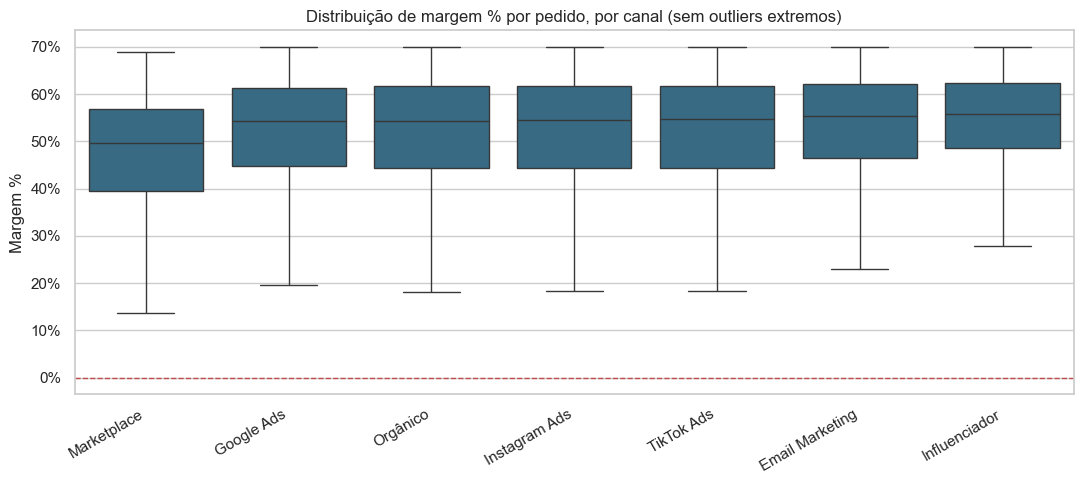

In [6]:
plt.figure(figsize=(11, 5))
order_box = vendas.groupby('canal')['margem_pct'].median().sort_values().index
sns.boxplot(data=vendas, x='canal', y='margem_pct', order=order_box, showfliers=False, color=PALETTE['primary'])
plt.axhline(0, color=PALETTE['bad'], linestyle='--', linewidth=1)
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(fmt_pct))
plt.xticks(rotation=30, ha='right')
plt.title('Distribuição de margem % por pedido, por canal (sem outliers extremos)')
plt.ylabel('Margem %')
plt.xlabel('')
plt.tight_layout()
plt.show()

**Leitura:** o boxplot mostra a *dispersão* de margem dentro de cada canal, não só a
média — um canal pode ter margem média razoável mas uma cauda grande de pedidos com
margem negativa. Canais com caixa inteira abaixo de 0 (ou mediana negativa) merecem
atenção prioritária na priorização de portfólio.

## 3. Margem por categoria de produto

In [7]:
por_categoria = (
    vendas.groupby('categoria')
    .agg(
        receita_liquida=('receita_liquida', 'sum'),
        margem_contribuicao=('margem_contribuicao', 'sum'),
        pedidos=('order_id', 'nunique'),
        desconto_pct_medio=('desconto_pct', 'mean'),
        taxa_devolucao=('devolvido', 'mean'),
    )
    .assign(margem_pct_agregada=lambda d: d['margem_contribuicao'] / d['receita_liquida'])
    .sort_values('receita_liquida', ascending=False)
)
por_categoria

,receita_liquida,margem_contribuicao,pedidos,desconto_pct_medio,taxa_devolucao,margem_pct_agregada
categoria,,,,,,
Moda,6692686.21,3645157.13,9708,0.079197,0.143078,0.544648
Beleza,5629140.05,3061752.89,8347,0.081869,0.148676,0.543911
Lifestyle,3864797.28,2091828.68,5629,0.080985,0.154912,0.541252
Acessórios,2702710.47,1471697.95,4074,0.078890,0.153412,0.544527


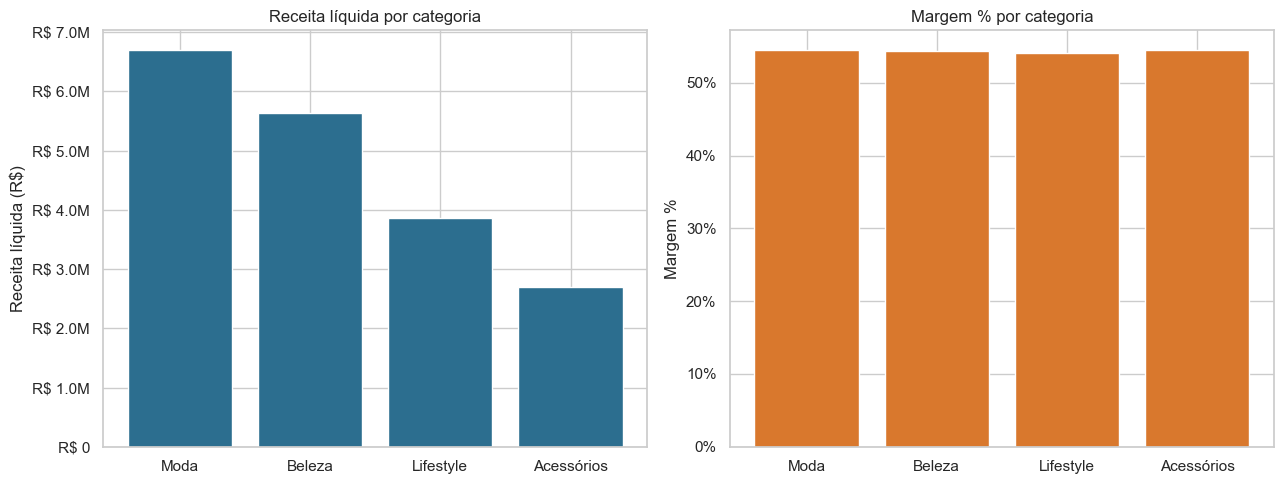

In [8]:
# 2 painéis de eixo único lado a lado, em vez de 1 gráfico com 2 eixos-Y
# (receita em R$ e margem em % não são comparáveis na mesma escala).
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
order = por_categoria.index.tolist()

axes[0].bar(order, por_categoria.loc[order, 'receita_liquida'], color=PALETTE['primary'])
axes[0].set_ylabel('Receita líquida (R$)')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(fmt_reais))
axes[0].set_title('Receita líquida por categoria')

axes[1].bar(order, por_categoria.loc[order, 'margem_pct_agregada'], color=PALETTE['accent'])
axes[1].set_ylabel('Margem %')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(fmt_pct))
axes[1].set_title('Margem % por categoria')

plt.tight_layout()
plt.show()

## 4. Desconto x margem

A hipótese de "Margem" do case aponta descontos mais agressivos como possível causa
de erosão de rentabilidade. Olhamos a relação direta entre `desconto_pct` e
`margem_pct` no nível de pedido.

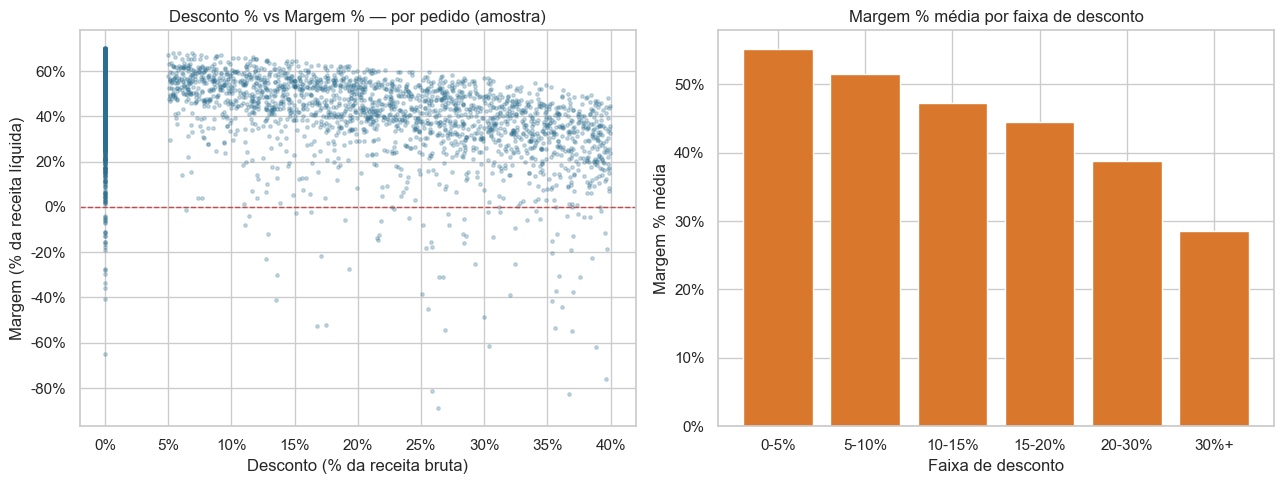

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
sample = vendas.sample(min(6000, len(vendas)), random_state=42)
ax.scatter(sample['desconto_pct'], sample['margem_pct'], s=6, alpha=0.25, color=PALETTE['primary'])
ax.axhline(0, color=PALETTE['bad'], linestyle='--', linewidth=1)
ax.set_xlabel('Desconto (% da receita bruta)')
ax.set_ylabel('Margem (% da receita líquida)')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(fmt_pct))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(fmt_pct))
ax.set_title('Desconto % vs Margem % — por pedido (amostra)')

ax = axes[1]
bins = [-0.001, 0.05, 0.10, 0.15, 0.20, 0.30, 1.0]
labels = ['0-5%', '5-10%', '10-15%', '15-20%', '20-30%', '30%+']
vendas_binned = vendas.copy()
vendas_binned['faixa_desconto'] = pd.cut(vendas_binned['desconto_pct'], bins=bins, labels=labels)
agg = vendas_binned.groupby('faixa_desconto', observed=True)['margem_pct'].mean()
ax.bar(agg.index.astype(str), agg.values, color=PALETTE['accent'])
ax.axhline(0, color=PALETTE['bad'], linestyle='--', linewidth=1)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(fmt_pct))
ax.set_xlabel('Faixa de desconto')
ax.set_ylabel('Margem % média')
ax.set_title('Margem % média por faixa de desconto')

plt.tight_layout()
plt.show()

In [10]:
print("Correlação (Pearson) desconto_pct x margem_pct:", vendas[['desconto_pct', 'margem_pct']].corr().iloc[0, 1].round(3))

Correlação (Pearson) desconto_pct x margem_pct: -0.535


**Leitura:** se a margem % média cai de forma consistente conforme a faixa de
desconto sobe, é evidência visual de que desconto agressivo é um dos motores da
erosão de margem. Testamos a significância estatística dessa correlação no notebook
03 (não fica só na leitura visual).

## 5. Devolução: quanto custa e onde se concentra

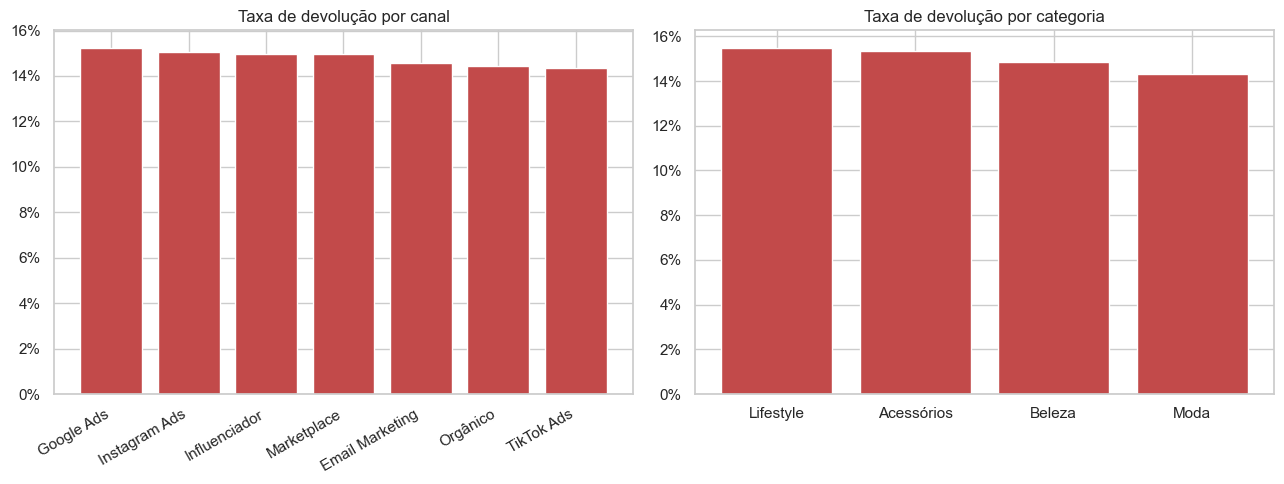

In [11]:
taxa_dev_canal = vendas.groupby('canal')['devolvido'].mean().sort_values(ascending=False)
taxa_dev_cat = vendas.groupby('categoria')['devolvido'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(taxa_dev_canal.index, taxa_dev_canal.values, color=PALETTE['bad'])
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(fmt_pct))
axes[0].set_title('Taxa de devolução por canal')
axes[0].tick_params(axis='x', rotation=30)
for lbl in axes[0].get_xticklabels():
    lbl.set_ha('right')

axes[1].bar(taxa_dev_cat.index, taxa_dev_cat.values, color=PALETTE['bad'])
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(fmt_pct))
axes[1].set_title('Taxa de devolução por categoria')

plt.tight_layout()
plt.show()

In [12]:
motivo = vendas.loc[vendas['devolvido'], 'motivo_devolucao'].value_counts()
margem_dev = vendas.groupby('devolvido')['margem_contribuicao'].agg(['mean', 'median', 'count'])
print("Margem de contribuição média: pedidos devolvidos vs não devolvidos")
print(margem_dev)
print()
print("Motivos de devolução (contagem):")
print(motivo)

impacto_margem_devolvidos = vendas.loc[vendas['devolvido'], 'margem_contribuicao'].sum()
print(f"\nMargem de contribuição somada nos pedidos devolvidos: R$ {impacto_margem_devolvidos:,.2f}")
print(f"({vendas['devolvido'].mean():.2%} dos pedidos são devoluções)")

Margem de contribuição média: pedidos devolvidos vs não devolvidos
                 mean  median  count
devolvido                           
False      370.159874  289.53  23631
True       369.078912  288.25   4127

Motivos de devolução (contagem):
motivo_devolucao
Produto com defeito    1039
Tamanho errado         1025
Atraso na entrega       808
Não gostei              669
Arrependimento          586
Name: count, dtype: int64

Margem de contribuição somada nos pedidos devolvidos: R$ 1,523,188.67
(14.87% dos pedidos são devoluções)


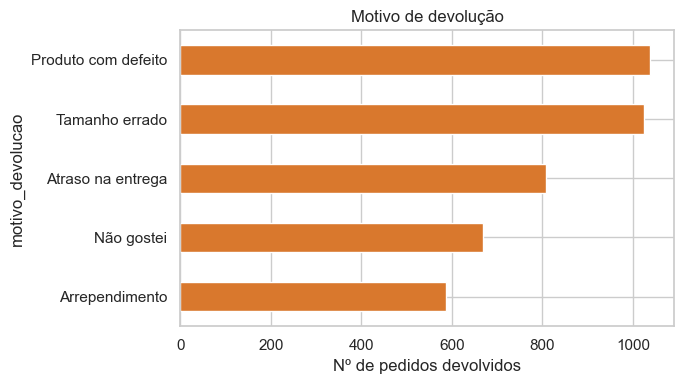

In [13]:
plt.figure(figsize=(7, 4))
motivo.plot(kind='barh', color=PALETTE['accent'])
plt.xlabel('Nº de pedidos devolvidos')
plt.title('Motivo de devolução')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Nota de premissa:** `margem_contribuicao` já reflete a receita líquida realizada
no pedido devolvido (a base não modela o estorno financeiro nem o custo logístico
reverso). Portanto o número acima é o **piso** do impacto de devolução — o custo
real para a empresa é esse valor de margem "perdida" *mais* o frete reverso e o
retrabalho operacional, que não estão quantificados nesta base.

## 6. Rentabilidade por produto (SKU)

Quais produtos concentram valor e quais destroem margem?

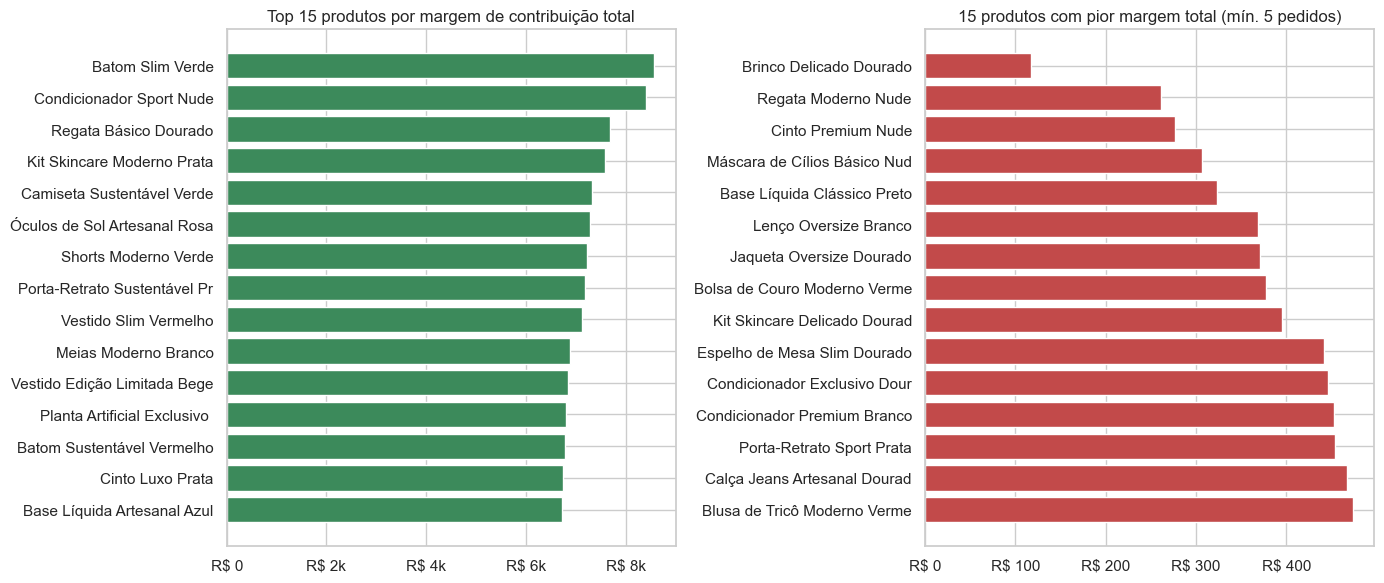

SKUs com margem de contribuição total negativa (mín. 5 pedidos): 0 de 2957


In [14]:
por_sku = (
    vendas.groupby(['sku_id', 'produto', 'categoria'])
    .agg(
        receita_liquida=('receita_liquida', 'sum'),
        margem_contribuicao=('margem_contribuicao', 'sum'),
        pedidos=('order_id', 'nunique'),
        margem_pct_media=('margem_pct', 'mean'),
    )
    .reset_index()
)
# só considera SKUs com volume mínimo para evitar ruído estatístico de 1-2 pedidos
por_sku_relevante = por_sku[por_sku['pedidos'] >= 5].copy()

top_margem = por_sku_relevante.sort_values('margem_contribuicao', ascending=False).head(15)
bottom_margem = por_sku_relevante.sort_values('margem_contribuicao', ascending=True).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(top_margem['produto'].str.slice(0, 28), top_margem['margem_contribuicao'], color=PALETTE['good'])
axes[0].set_title('Top 15 produtos por margem de contribuição total')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(fmt_reais))
axes[0].invert_yaxis()

axes[1].barh(bottom_margem['produto'].str.slice(0, 28), bottom_margem['margem_contribuicao'], color=PALETTE['bad'])
axes[1].set_title('15 produtos com pior margem total (mín. 5 pedidos)')
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(fmt_reais))
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"SKUs com margem de contribuição total negativa (mín. 5 pedidos): "
      f"{(por_sku_relevante['margem_contribuicao'] < 0).sum()} de {len(por_sku_relevante)}")

## 7. Marketing: qualidade da aquisição por canal

> Lembrete de qualidade de dados (notebook 01): `marketing.csv` cobre jan/2023 a
> dez/2025, mas `vendas.csv` só vai até jan/2024. Os gráficos abaixo usam
> `marketing.csv` isoladamente (CAC, ROAS e investimento **declarados** pela própria
> base) — não são reconciliados com receita real de `vendas.csv` fora da janela
> comum.

In [15]:
por_canal_mkt = (
    marketing.groupby('canal')
    .agg(
        investimento_reais=('investimento_reais', 'sum'),
        receita_gerada=('receita_gerada', 'sum'),
        conversoes=('conversoes', 'sum'),
        cac_medio=('cac', 'mean'),
        roas_medio=('roas', 'mean'),
    )
    .sort_values('investimento_reais', ascending=False)
)
por_canal_mkt

,investimento_reais,receita_gerada,conversoes,cac_medio,roas_medio
canal,,,,,
Marketplace,32682629.69,9.879591e+07,17894187,4.385963,3.004519
Google Ads,30224839.25,1.065574e+08,16118323,4.269627,3.513536
Instagram Ads,30165772.33,1.359386e+08,15360484,4.716699,4.426390
Orgânico,29808867.75,8.964926e+07,16401820,4.655960,2.993434
TikTok Ads,29770101.07,1.390634e+08,17009948,3.954672,4.667111
Email Marketing,29700531.98,9.104621e+07,16563197,4.291546,2.997897
Influenciador,28061599.02,2.175780e+08,15940484,4.173484,7.691548


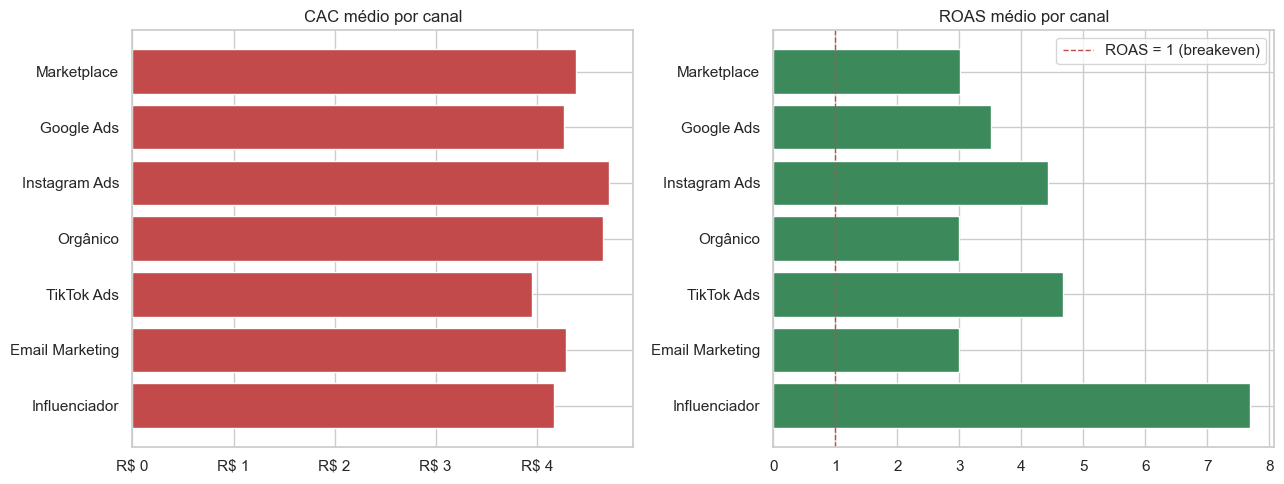

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
order = por_canal_mkt.index.tolist()

axes[0].barh(order, por_canal_mkt.loc[order, 'cac_medio'], color=PALETTE['bad'])
axes[0].set_title('CAC médio por canal')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(fmt_reais))
axes[0].invert_yaxis()

axes[1].barh(order, por_canal_mkt.loc[order, 'roas_medio'], color=PALETTE['good'])
axes[1].set_title('ROAS médio por canal')
axes[1].axvline(1, color=PALETTE['bad'], linestyle='--', linewidth=1, label='ROAS = 1 (breakeven)')
axes[1].legend()
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

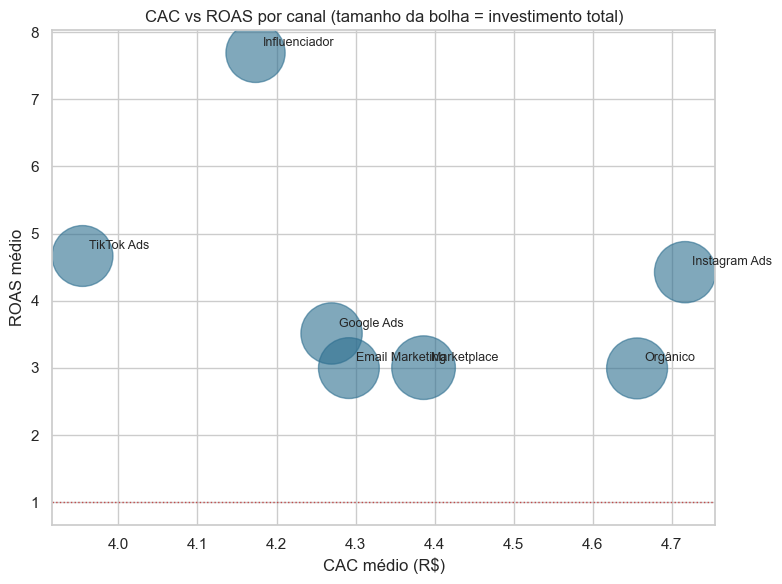

In [17]:
plt.figure(figsize=(8, 6))
scatter_data = marketing.groupby('canal').agg(cac_medio=('cac','mean'), roas_medio=('roas','mean'),
                                               investimento_total=('investimento_reais','sum'))
sizes = (scatter_data['investimento_total'] / scatter_data['investimento_total'].max()) * 2000 + 100
plt.scatter(scatter_data['cac_medio'], scatter_data['roas_medio'], s=sizes, alpha=0.6, color=PALETTE['primary'])
for canal, row in scatter_data.iterrows():
    plt.annotate(canal, (row['cac_medio'], row['roas_medio']), fontsize=9,
                 xytext=(5, 5), textcoords='offset points')
plt.xlabel('CAC médio (R$)')
plt.ylabel('ROAS médio')
plt.title('CAC vs ROAS por canal (tamanho da bolha = investimento total)')
plt.axhline(1, color=PALETTE['bad'], linestyle=':', linewidth=1)
plt.tight_layout()
plt.show()

**Leitura:** canais no quadrante CAC alto / ROAS baixo são candidatos a
realocação de budget — exatamente a pergunta do Módulo A do case ("quais canais
devem receber mais ou menos investimento"). Cruzamos isso com margem por canal
(seção 2) para saber se o canal também entrega clientes rentáveis, não só volume.

## 8. Clientes: segmentação, LTV e fidelidade

> Conforme decisão do notebook 01, esta seção usa **somente `clientes.csv`**, sem
> tentar juntar com `vendas.csv` (a ligação por `customer_id` não é confiável — ver
> seção 5 do notebook 01).

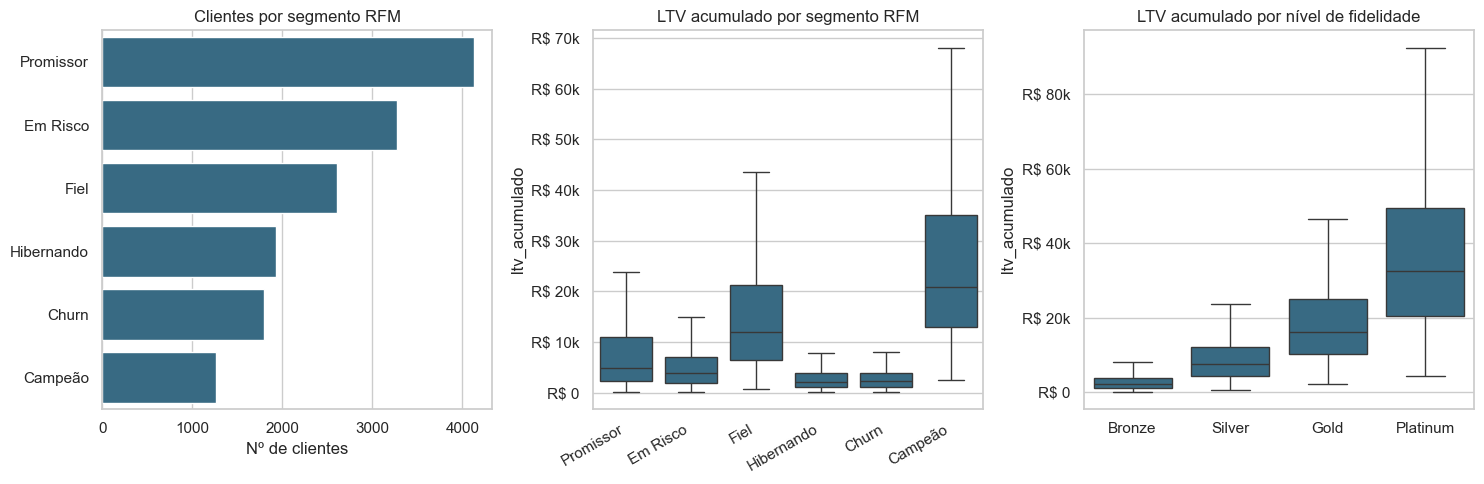

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

seg_order = clientes['segmento_rfm'].value_counts().index
sns.countplot(data=clientes, y='segmento_rfm', order=seg_order, ax=axes[0], color=PALETTE['primary'])
axes[0].set_title('Clientes por segmento RFM')
axes[0].set_xlabel('Nº de clientes')
axes[0].set_ylabel('')

sns.boxplot(data=clientes, x='segmento_rfm', y='ltv_acumulado', order=seg_order, ax=axes[1], showfliers=False, color=PALETTE['primary'])
axes[1].set_title('LTV acumulado por segmento RFM')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(fmt_reais))
axes[1].tick_params(axis='x', rotation=30)
for lbl in axes[1].get_xticklabels():
    lbl.set_ha('right')
axes[1].set_xlabel('')

nivel_order = ['Bronze', 'Silver', 'Gold', 'Platinum']
sns.boxplot(data=clientes, x='nivel_fidelidade', y='ltv_acumulado', order=nivel_order, ax=axes[2], showfliers=False, color=PALETTE['primary'])
axes[2].set_title('LTV acumulado por nível de fidelidade')
axes[2].yaxis.set_major_formatter(mtick.FuncFormatter(fmt_reais))
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()

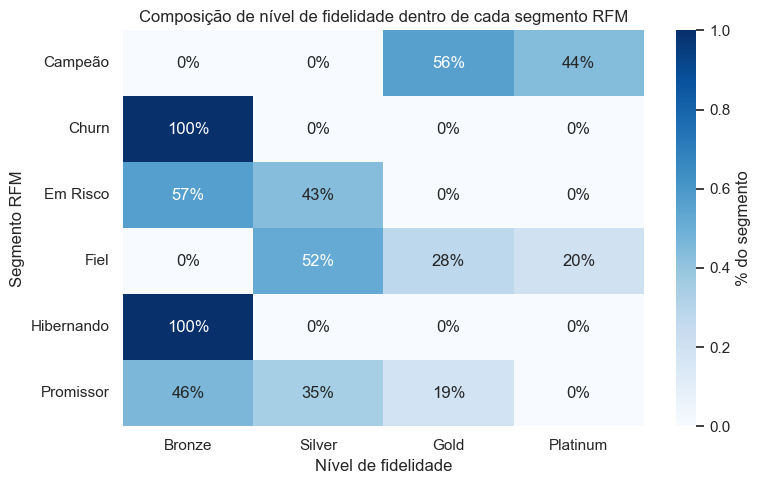

In [19]:
tab = pd.crosstab(clientes['segmento_rfm'], clientes['nivel_fidelidade'], normalize='index')
tab = tab[nivel_order]
plt.figure(figsize=(8, 5))
sns.heatmap(tab, annot=True, fmt='.0%', cmap='Blues', cbar_kws={'label': '% do segmento'})
plt.title('Composição de nível de fidelidade dentro de cada segmento RFM')
plt.ylabel('Segmento RFM')
plt.xlabel('Nível de fidelidade')
plt.tight_layout()
plt.show()

**Leitura:** segmentos como "Em Risco" e "Hibernando" com LTV ainda relevante são
candidatos a ação de retenção; "Campeão"/"Fiel" concentrando LTV alto validam onde
proteger receita. Isso alimenta diretamente a pergunta do case sobre quais
segmentos merecem retenção, upsell ou redução de investimento.

## 9. Operações: estoque, ruptura e giro

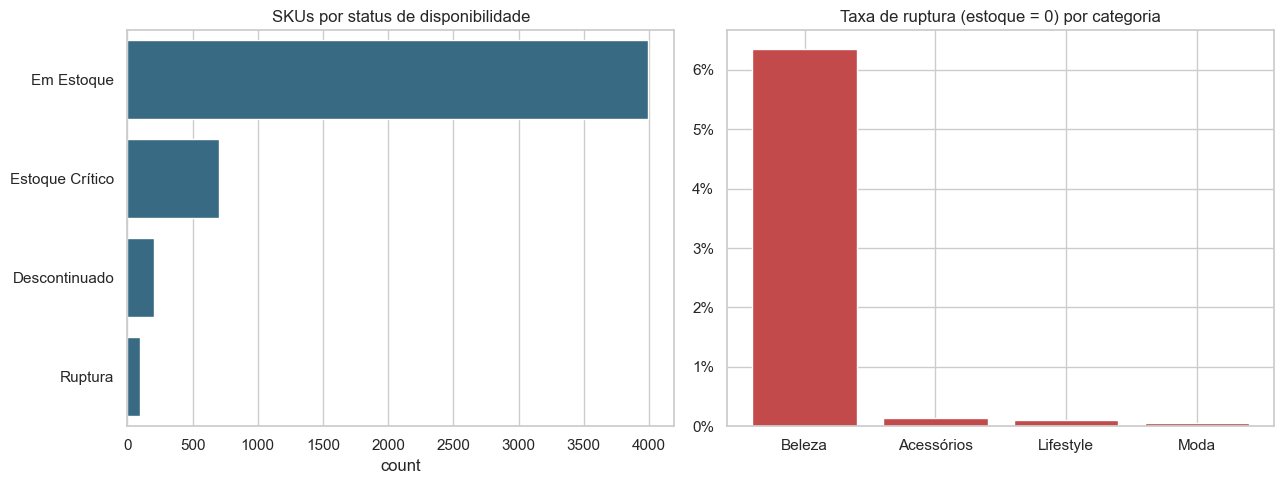

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

status_order = estoque['status_disponibilidade'].value_counts().index
sns.countplot(data=estoque, y='status_disponibilidade', order=status_order, ax=axes[0], color=PALETTE['primary'])
axes[0].set_title('SKUs por status de disponibilidade')
axes[0].set_ylabel('')

ruptura_cat = estoque.groupby('categoria')['ruptura'].mean().sort_values(ascending=False)
axes[1].bar(ruptura_cat.index, ruptura_cat.values, color=PALETTE['bad'])
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(fmt_pct))
axes[1].set_title('Taxa de ruptura (estoque = 0) por categoria')

plt.tight_layout()
plt.show()

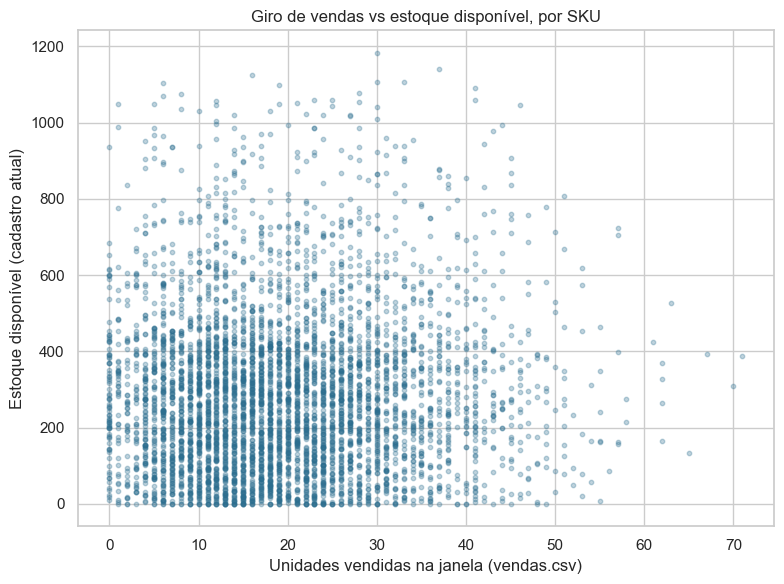

SKUs com 0 vendas na janela mas estoque disponível > ponto de pedido: 72 de 5000 — candidatos a estoque parado/dead stock.
SKUs com alto giro (top quartil) e em ruptura: 21 — candidatos a perda de venda por ruptura.


In [21]:
# Cruza giro real de vendas (quantidade vendida por SKU, na janela de vendas.csv)
# com o estoque disponível cadastrado — identifica excesso de estoque parado
# (baixo giro, estoque alto) e risco de ruptura (giro alto, estoque baixo).
giro_sku = vendas.groupby('sku_id')['quantidade'].sum().rename('unidades_vendidas')
cruz = estoque.set_index('sku_id').join(giro_sku, how='left')
cruz['unidades_vendidas'] = cruz['unidades_vendidas'].fillna(0)

plt.figure(figsize=(8, 6))
plt.scatter(cruz['unidades_vendidas'], cruz['estoque_disponivel'], s=10, alpha=0.3, color=PALETTE['primary'])
plt.xlabel('Unidades vendidas na janela (vendas.csv)')
plt.ylabel('Estoque disponível (cadastro atual)')
plt.title('Giro de vendas vs estoque disponível, por SKU')
plt.tight_layout()
plt.show()

print(f"SKUs com 0 vendas na janela mas estoque disponível > ponto de pedido: "
      f"{((cruz['unidades_vendidas']==0) & (cruz['estoque_disponivel']>cruz['ponto_pedido'])).sum()} "
      f"de {len(cruz)} — candidatos a estoque parado/dead stock.")
print(f"SKUs com alto giro (top quartil) e em ruptura: "
      f"{((cruz['unidades_vendidas']>cruz['unidades_vendidas'].quantile(0.75)) & (cruz['ruptura'])).sum()} "
      f"— candidatos a perda de venda por ruptura.")

**Nota de premissa:** `estoque.csv` é uma **fotografia do estoque atual** (não uma
série histórica), enquanto `vendas.csv` é o **acumulado de 13 meses**. O cruzamento
acima é direcional (identifica candidatos a dead stock / risco de ruptura), não uma
medida exata de giro de estoque no tempo — não há como saber o nível de estoque no
momento exato de cada venda.

## 10. Atendimento: temas, custo e satisfação

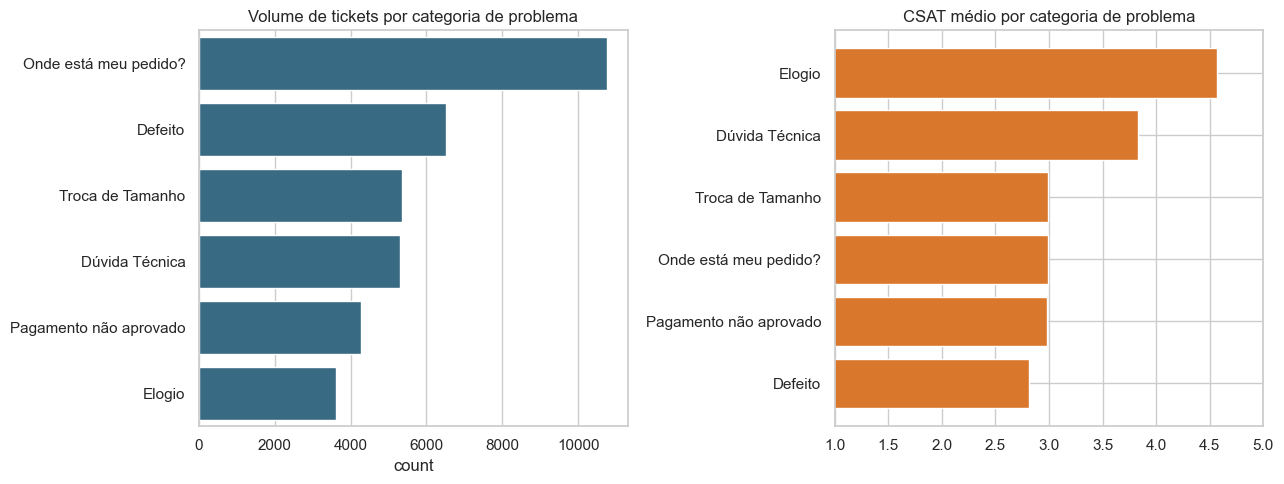

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cat_order = atendimento['categoria_problema'].value_counts().index
sns.countplot(data=atendimento, y='categoria_problema', order=cat_order, ax=axes[0], color=PALETTE['primary'])
axes[0].set_title('Volume de tickets por categoria de problema')
axes[0].set_ylabel('')

csat_cat = atendimento.groupby('categoria_problema')['nota_csat'].mean().sort_values()
axes[1].barh(csat_cat.index, csat_cat.values, color=PALETTE['accent'])
axes[1].set_title('CSAT médio por categoria de problema')
axes[1].set_xlim(1, 5)

plt.tight_layout()
plt.show()

In [23]:
custo_cat = atendimento.groupby('categoria_problema')['custo_operacional_ticket'].agg(['mean', 'sum', 'count'])
custo_cat = custo_cat.sort_values('sum', ascending=False)
custo_cat.columns = ['custo_medio_ticket', 'custo_total', 'n_tickets']
custo_cat

,custo_medio_ticket,custo_total,n_tickets
categoria_problema,,,
Onde está meu pedido?,14.831398,159660.0,10765
Defeito,14.839760,96592.0,6509
Troca de Tamanho,14.799440,79325.0,5360
Dúvida Técnica,14.845314,78888.0,5314
Pagamento não aprovado,14.916141,63856.0,4281
Elogio,14.937413,53939.0,3611


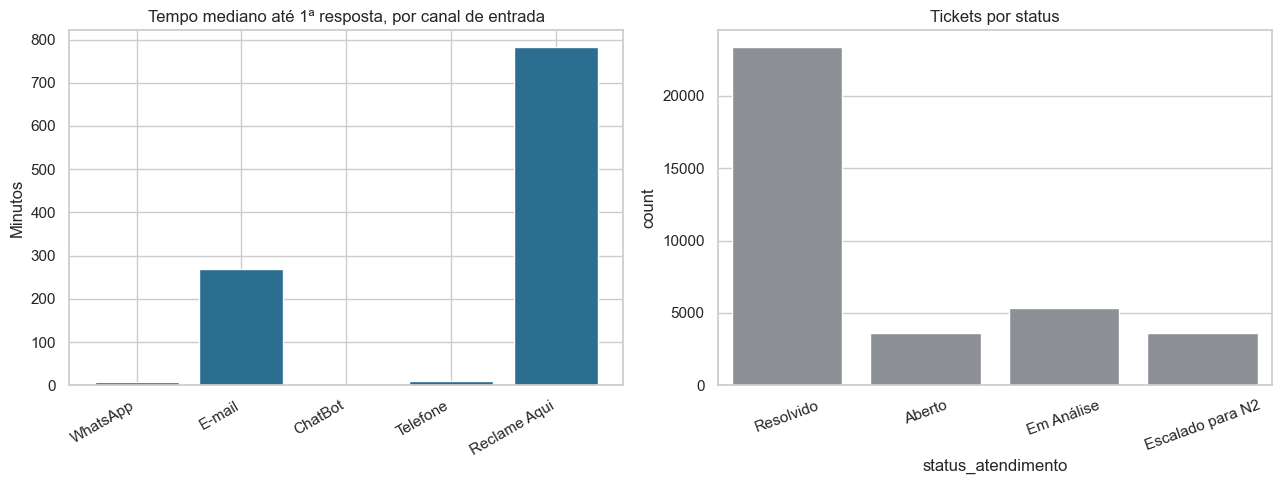

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

canal_order = atendimento['canal_entrada'].value_counts().index
tempo_canal = atendimento.groupby('canal_entrada')['tempo_primeira_resposta_minutos'].median().reindex(canal_order)
axes[0].bar(tempo_canal.index, tempo_canal.values, color=PALETTE['primary'])
axes[0].set_title('Tempo mediano até 1ª resposta, por canal de entrada')
axes[0].set_ylabel('Minutos')
axes[0].tick_params(axis='x', rotation=30)
for lbl in axes[0].get_xticklabels():
    lbl.set_ha('right')

sns.countplot(data=atendimento, x='status_atendimento', ax=axes[1], color=PALETTE['neutral'])
axes[1].set_title('Tickets por status')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

**Leitura:** categorias com volume alto **e** CSAT baixo **e** custo por ticket alto
são as prioritárias para triagem automatizada (Módulo B do case). Note que
`"Onde está meu pedido?"` tende a ser o tema mais volumoso em operações de
e-commerce com problema de entrega — vale conferir se é o caso aqui e se converge
com a taxa de devolução por atraso vista na seção 5.

> Lembrete de qualidade de dados: só 27,5% dos tickets (`atendimento.order_id`)
> encontram um pedido correspondente em `vendas.csv`, principalmente por causa da
> janela de tempo mais curta de `vendas.csv` (ver notebook 01, seção 6). O
> cruzamento ticket↔pedido individual deve ser interpretado como uma amostra
> parcial, não a população completa de tickets pós-venda.

---

## 11. Corte por faixa de ticket (tamanho do pedido)

Divide os pedidos em 5 grupos de tamanho igual (quintis de `receita_liquida`) e
compara margem, desconto e frete entre eles — um corte que ainda não tínhamos
feito e que a matriz de KPIs do case pede explicitamente.

In [25]:
qs = vendas['receita_liquida'].quantile([0, .2, .4, .6, .8, 1.0]).values
bins_ticket = list(qs)
bins_ticket[0] -= 1
bins_ticket[-1] += 1
labels_ticket = ['Q1 (menor)', 'Q2', 'Q3', 'Q4', 'Q5 (maior)']
vendas['faixa_ticket'] = pd.cut(vendas['receita_liquida'], bins=bins_ticket, labels=labels_ticket)

por_ticket = vendas.groupby('faixa_ticket', observed=True).agg(
    receita_media=('receita_liquida', 'mean'),
    margem_pct=('margem_pct', 'mean'),
    desconto_pct=('desconto_pct', 'mean'),
    frete_pct_receita=('custo_frete', lambda s: (s / vendas.loc[s.index, 'receita_liquida']).mean()),
    n=('order_id', 'count'),
)
por_ticket

,receita_media,margem_pct,desconto_pct,frete_pct_receita,n
faixa_ticket,,,,,
Q1 (menor),157.816852,0.297279,0.109936,0.245680,5552
Q2,330.745671,0.523451,0.093134,0.026655,5551
Q3,543.991592,0.542894,0.082560,0.012583,5553
Q4,841.900209,0.552581,0.071794,0.008533,5550
Q5 (maior),1528.068112,0.564127,0.044167,0.004823,5552


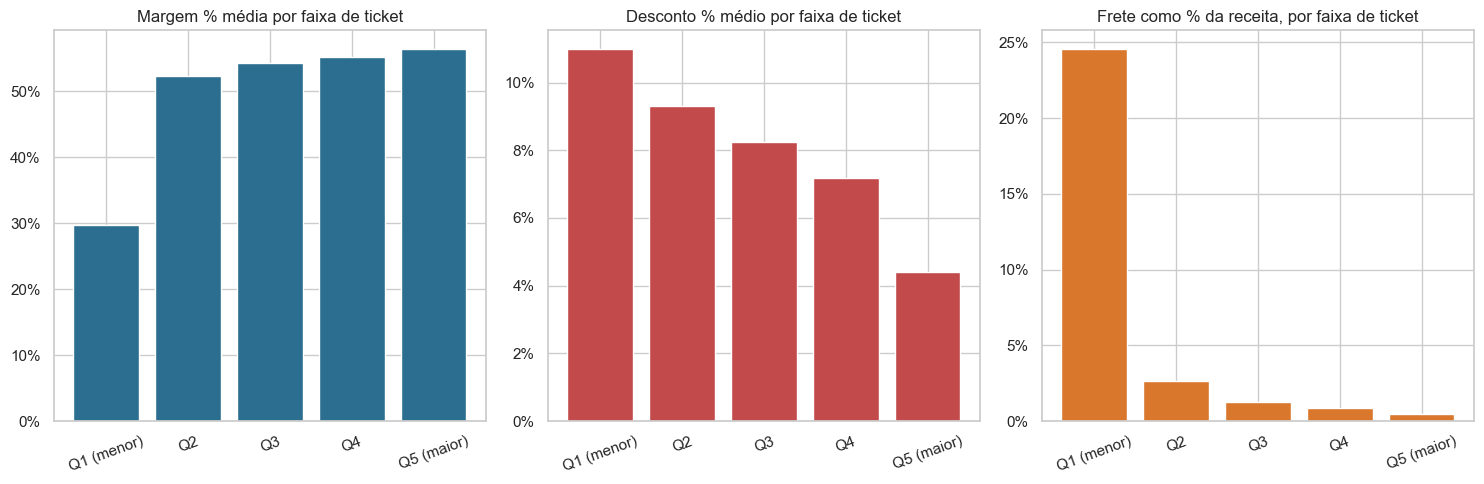

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(por_ticket.index, por_ticket['margem_pct'], color=PALETTE['primary'])
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(fmt_pct))
axes[0].set_title('Margem % média por faixa de ticket')

axes[1].bar(por_ticket.index, por_ticket['desconto_pct'], color=PALETTE['bad'])
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(fmt_pct))
axes[1].set_title('Desconto % médio por faixa de ticket')

axes[2].bar(por_ticket.index, por_ticket['frete_pct_receita'], color=PALETTE['accent'])
axes[2].yaxis.set_major_formatter(mtick.FuncFormatter(fmt_pct))
axes[2].set_title('Frete como % da receita, por faixa de ticket')

for ax in axes:
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

**Leitura:** o pedido pequeno (Q1, receita líquida média de R$158) tem margem de
**29,7%** contra **56,4%** no pedido grande (Q5, média R$1.528) — a maior amplitude
de qualquer corte feito nesta notebook. Duas causas mecânicas explicam isso, e as
duas já apareceram antes nesta análise:

1. **Frete é um custo quase fixo por pedido** — como % da receita, ele cai de
   24,6% no Q1 para 0,5% no Q5. Pedido pequeno "carrega" o mesmo frete que um
   grande, só que dividido por muito menos receita.
2. **Desconto concentra-se nos pedidos pequenos** — 11,0% de desconto médio no
   Q1 contra 4,4% no Q5 (mesmo padrão do Teste 4 do notebook 03, agora visto
   pela ótica do tamanho do pedido).

Uma regressão rápida confirma que isso não é só reflexo do desconto: `margem_pct
~ desconto_pct` sozinho tem R²=28,6% (Teste 4); adicionando o log da receita do
pedido, o R² sobe para **52,1%** — tamanho de pedido é um driver adicional e
independente, não uma reformulação do mesmo efeito.

**Implicação de negócio:** qualquer política de frete grátis ou desconto
deveria ter piso de valor mínimo de pedido — hoje o pedido pequeno é
estruturalmente o menos rentável, e nenhuma política atual parece reconhecer
isso.

---

## 12. Corte por região geográfica

`clientes.csv` tem `estado` (27 valores) e `cidade`. Como a ligação
`customer_id` → `vendas.csv` não é confiável (ver notebook 01), fazemos este
corte **só em `clientes.csv`** — mesma decisão de escopo da seção 8 — o que na
verdade é uma vantagem aqui: evita herdar o problema de pseudo-replicação.

In [27]:
macro_regiao = {
    'AM': 'Norte', 'PA': 'Norte', 'RR': 'Norte', 'AP': 'Norte', 'TO': 'Norte', 'RO': 'Norte', 'AC': 'Norte',
    'PE': 'Nordeste', 'PI': 'Nordeste', 'CE': 'Nordeste', 'PB': 'Nordeste', 'SE': 'Nordeste',
    'AL': 'Nordeste', 'MA': 'Nordeste', 'RN': 'Nordeste', 'BA': 'Nordeste',
    'GO': 'Centro-Oeste', 'MT': 'Centro-Oeste', 'MS': 'Centro-Oeste', 'DF': 'Centro-Oeste',
    'SP': 'Sudeste', 'MG': 'Sudeste', 'RJ': 'Sudeste', 'ES': 'Sudeste',
    'PR': 'Sul', 'SC': 'Sul', 'RS': 'Sul',
}
clientes['macro_regiao'] = clientes['estado'].map(macro_regiao)

por_regiao = clientes.groupby('macro_regiao')['ltv_acumulado'].agg(['median', 'mean', 'count']).sort_values('median', ascending=False)
por_regiao

,median,mean,count
macro_regiao,,,
Sudeste,5724.850,12540.722817,4153
Sul,5045.955,10502.972899,1790
Centro-Oeste,4860.580,9510.766512,1591
Norte,4563.190,7543.973037,1205
Nordeste,4300.900,7025.795953,6261


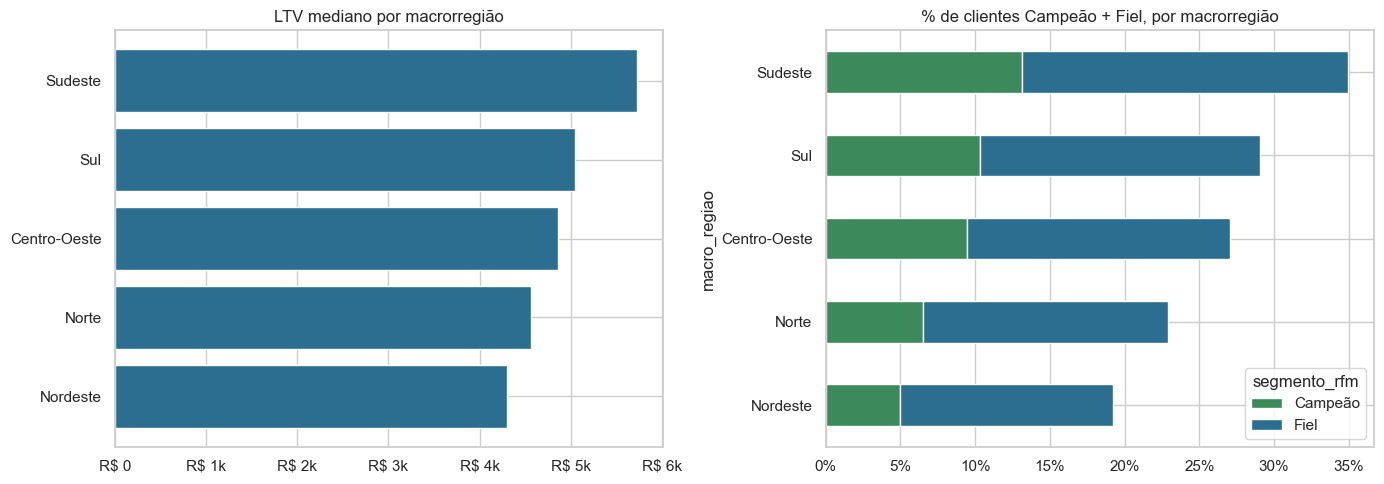

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_reg = por_regiao.index.tolist()
axes[0].barh(order_reg, por_regiao.loc[order_reg, 'median'], color=PALETTE['primary'])
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(fmt_reais))
axes[0].set_title('LTV mediano por macrorregião')
axes[0].invert_yaxis()

tab_reg = pd.crosstab(clientes['macro_regiao'], clientes['segmento_rfm'], normalize='index').loc[order_reg]
tab_reg[['Campeão', 'Fiel']].plot(kind='barh', stacked=True, ax=axes[1], color=[PALETTE['good'], PALETTE['primary']])
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(fmt_pct))
axes[1].set_title('% de clientes Campeão + Fiel, por macrorregião')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [29]:
from scipy import stats

grupos_regiao = [g['ltv_acumulado'].dropna().values for _, g in clientes.groupby('macro_regiao')]
H, p = stats.kruskal(*grupos_regiao)
n_r = sum(len(g) for g in grupos_regiao)
k_r = len(grupos_regiao)
eps_r = (H - k_r + 1) / (n_r - k_r)
print(f"Kruskal-Wallis LTV x macrorregião: H={H:.2f}  p={p:.4g}  epsilon²={eps_r:.4f}")

Kruskal-Wallis LTV x macrorregião: H=214.78  p=2.49e-45  epsilon²=0.0141


**Leitura:** diferença estatisticamente real (p≈2,5×10⁻⁴⁵, n=15.000) mas de
efeito **pequeno** (ε²=0,014) — Sudeste concentra o LTV mediano mais alto
(R$5.725) e a maior fatia de clientes Campeão+Fiel (35,0%), contra Nordeste no
outro extremo (LTV mediano R$4.301, 19,3% Campeão+Fiel). Não é a variável mais
forte da base — desconto e canal continuam explicando muito mais — mas é um
critério de segmentação geográfica válido para campanhas regionais de retenção,
que a empresa hoje não usa (a base não tem nenhuma coluna de canal/campanha
segmentada por região).

---

## 13. Ponte de margem (da receita a preço cheio à margem realizada)

**Objetivo deste notebook:** construir a "ponte de margem" (margin bridge) —
uma reconciliação aditiva, em R$, que parte da receita a preço cheio e chega na
margem que de fato virou caixa, decompondo cada real perdido no caminho em um
efeito nomeado: **mix de categoria, desconto, CMV, frete e devolução/não-
realização**.

Diferença em relação ao notebook 03: lá, cada efeito foi testado
**isoladamente** (é significativo? qual o tamanho do efeito?). Aqui, os mesmos
5 efeitos são **empilhados numa única reconciliação que soma exatamente** ao
gap entre a margem contábil (54,4%) e a margem realizada (40,8%) já
estabelecidas no notebook 03 — Teste 15. Nenhum número novo é inventado; este
notebook é uma reorganização visual e aditiva de fatos já validados.

**Janela de referência:** ano de 2023 completo (12 meses, 26.538 pedidos) — não
a janela de 13 meses usada no notebook 03, para reportar um "ano" sem precisar
anualizar um mês parcial de janeiro/2024.

### 13.1 Os 5 blocos da ponte, calculados direto da base

**Premissas declaradas:**
- "Preço cheio" = `receita_bruta` (antes de qualquer desconto).
- CMV = `custo_produto` (custo de aquisição da mercadoria vendida, por pedido).
- Frete = `custo_frete` (custo logístico de saída, por pedido).
- "Não-realizado" = pedidos devolvidos (`devolvido`) ou com `status_pagamento`
  diferente de "Aprovado" — o mesmo critério do Teste 15 do notebook 03.
- Efeito mix = a diferença entre a margem real (ponderada pela participação de
  receita de cada categoria) e a margem que existiria se as 4 categorias
  tivessem participação igual (25% cada) na própria margem % observada. Isola
  "o mix ajuda ou atrapalha" sem depender de um período anterior para
  comparar (o notebook 01/Teste 1 já mostrou que não há tendência temporal
  seguindo comparar).

In [30]:
vendas_2023 = vendas[vendas['data_pedido'].dt.year == 2023].copy()
print(f"Pedidos em 2023 (ano completo): {len(vendas_2023):,}")

Pedidos em 2023 (ano completo): 26,538


In [31]:
receita_bruta = vendas_2023['receita_bruta'].sum()
desconto = vendas_2023['desconto_reais'].sum()
custo_produto = vendas_2023['custo_produto'].sum()
custo_frete = vendas_2023['custo_frete'].sum()
receita_liquida = vendas_2023['receita_liquida'].sum()
margem_contabil_rs = vendas_2023['margem_contribuicao'].sum()

# efeito mix: real (ponderado pela receita de cada categoria) vs. peso igual (25% cada)
por_cat = vendas_2023.groupby('categoria').agg(receita=('receita_liquida', 'sum'), margem_rs=('margem_contribuicao', 'sum'))
por_cat['margem_pct'] = por_cat['margem_rs'] / por_cat['receita']
n_cat = len(por_cat)
margem_peso_igual = (por_cat['margem_pct'] * (1 / n_cat)).sum() * receita_liquida
efeito_mix = margem_contabil_rs - margem_peso_igual

realizado = vendas_2023[(~vendas_2023['devolvido']) & (vendas_2023['status_pagamento'] == 'Aprovado')]
margem_realizada_rs = realizado['margem_contribuicao'].sum()
efeito_nao_realizado = margem_contabil_rs - margem_realizada_rs

print(f"Receita bruta (preço cheio):        R$ {receita_bruta:>14,.2f}")
print(f"(-) Desconto concedido:             R$ {desconto:>14,.2f}")
print(f" = Receita líquida:                 R$ {receita_liquida:>14,.2f}")
print(f"(-) CMV (custo do produto):         R$ {custo_produto:>14,.2f}")
print(f"(-) Frete (custo logístico):        R$ {custo_frete:>14,.2f}")
print(f"(-) Efeito mix de categoria:        R$ {efeito_mix:>14,.2f}   ({efeito_mix/receita_liquida*100:.3f}% da receita líquida)")
print(f" = Margem de contribuição (contábil): R$ {margem_contabil_rs:>12,.2f}  ({margem_contabil_rs/receita_liquida:.2%})")
print(f"(-) Efeito devolução/não-aprovado:   R$ {efeito_nao_realizado:>14,.2f}")
print(f" = Margem realizada:                R$ {margem_realizada_rs:>14,.2f}  ({margem_realizada_rs/receita_liquida:.2%})")

Receita bruta (preço cheio):        R$  19,653,893.38
(-) Desconto concedido:             R$   1,567,098.22
 = Receita líquida:                 R$  18,086,795.16
(-) CMV (custo do produto):         R$   7,929,036.67
(-) Frete (custo logístico):        R$     324,826.55
(-) Efeito mix de categoria:        R$       1,974.61   (0.011% da receita líquida)
 = Margem de contribuição (contábil): R$ 9,832,931.94  (54.37%)
(-) Efeito devolução/não-aprovado:   R$   2,450,030.93
 = Margem realizada:                R$   7,382,901.01  (40.82%)


### 13.2 A ponte, visualmente

Gráfico de cascata (waterfall) — cada barra flutuante é um efeito, os totais
(cinza-escuro) são pontos de chegada. Ordem: preço cheio → desconto → CMV →
frete → mix → margem contábil → não-realização → margem realizada.

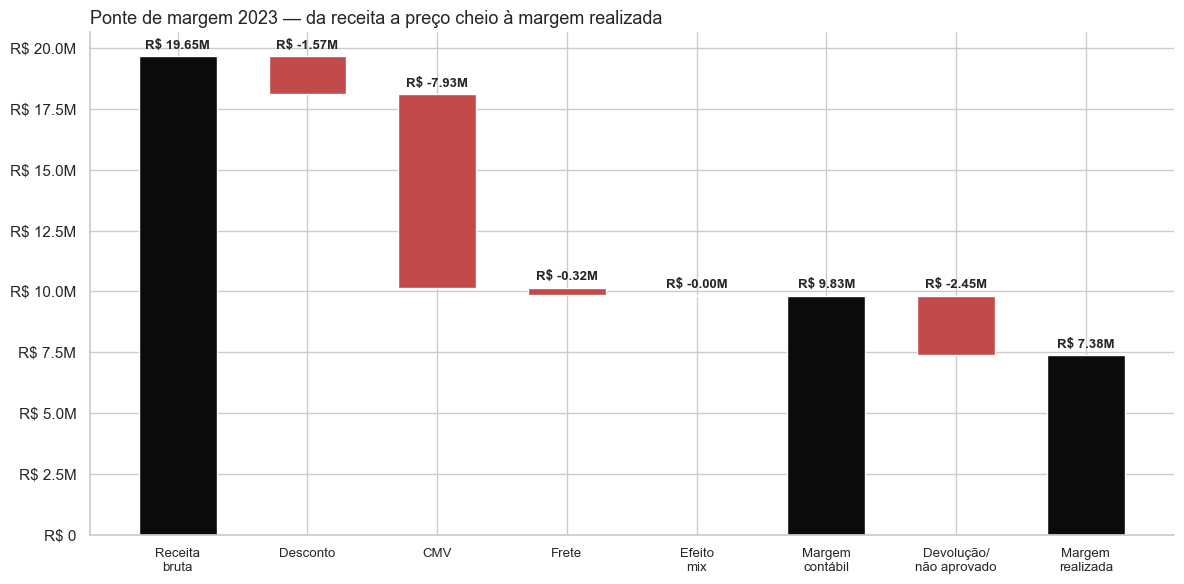

In [32]:
labels = ['Receita\nbruta', 'Desconto', 'CMV', 'Frete', 'Efeito\nmix',
          'Margem\ncontábil', 'Devolução/\nnão aprovado', 'Margem\nrealizada']
deltas = [receita_bruta, -desconto, -custo_produto, -custo_frete, -efeito_mix,
          0, -efeito_nao_realizado, 0]
is_total = [True, False, False, False, False, True, False, True]

# calcula posicao de cada barra (cascata)
running = 0
bottoms, heights, colors = [], [], []
cumulative = []
for i, (d, tot) in enumerate(zip(deltas, is_total)):
    if tot:
        if i == 0:
            running = receita_bruta
            bottoms.append(0)
            heights.append(running)
            colors.append(PALETTE['total'])
        else:
            bottoms.append(0)
            heights.append(running)
            colors.append(PALETTE['total'])
    else:
        bottoms.append(running + d if d < 0 else running)
        heights.append(abs(d))
        colors.append(PALETTE['bad'] if d < 0 else PALETTE['good'])
        running += d
    cumulative.append(running)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(labels, heights, bottom=bottoms, color=colors, width=0.6)
for i, (b, h, bot) in enumerate(zip(bars, heights, bottoms)):
    val = deltas[i] if not is_total[i] else cumulative[i]
    y = bot + h + (receita_bruta * 0.015)
    ax.text(b.get_x() + b.get_width() / 2, y, f'R$ {val/1e6:,.2f}M', ha='center', fontsize=9.5, fontweight='bold')

ax.yaxis.set_major_formatter(mtick.FuncFormatter(fmt_reais))
ax.set_title('Ponte de margem 2023 — da receita a preço cheio à margem realizada', loc='left', fontsize=13)
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=0, fontsize=9.5)
plt.tight_layout()
plt.show()

### 13.3 Reconciliação — os números batem com o resto do projeto?

Este é o ponto do notebook que funciona como checagem cruzada: cada total da
ponte precisa reconciliar exatamente com o que já foi publicado no notebook 03
e no `outputs/diagnostico_vertice.html`.

In [33]:
checagens = {
    'Margem contábil %': (margem_contabil_rs / receita_liquida, 0.5437, 'Notebook 03, Teste 15 / relatório: 54,37%'),
    'Margem realizada %': (margem_realizada_rs / receita_liquida, 0.4082, 'Notebook 03, Teste 15 / relatório: 40,82%'),
    'Desconto concedido (R$, 2023)': (desconto, 1_567_098, 'Relatório (Causa 1): R$ 1.567.098'),
    'Gap margem contábil -> realizada (R$, 2023)': (efeito_nao_realizado, 2_450_031, 'Relatório (Causa 2): R$ 2.450.031'),
}

print(f"{'Métrica':<45}{'Calculado aqui':>18}{'Publicado antes':>18}{'Confere?':>12}")
for nome, (calc, publicado, fonte) in checagens.items():
    if calc > 1:
        calc_s, pub_s = f'{calc:,.0f}', f'{publicado:,.0f}'
        confere = abs(calc - publicado) < 1
    else:
        calc_s, pub_s = f'{calc:.4f}', f'{publicado:.4f}'
        confere = abs(calc - publicado) < 0.001
    print(f"{nome:<45}{calc_s:>18}{pub_s:>18}{('SIM' if confere else 'NAO — DIVERGENCIA'):>12}")
    print(f"   fonte: {fonte}")

Métrica                                          Calculado aqui   Publicado antes    Confere?
Margem contábil %                                        0.5437            0.5437         SIM
   fonte: Notebook 03, Teste 15 / relatório: 54,37%
Margem realizada %                                       0.4082            0.4082         SIM
   fonte: Notebook 03, Teste 15 / relatório: 40,82%
Desconto concedido (R$, 2023)                         1,567,098         1,567,098         SIM
   fonte: Relatório (Causa 1): R$ 1.567.098
Gap margem contábil -> realizada (R$, 2023)           2,450,031         2,450,031         SIM
   fonte: Relatório (Causa 2): R$ 2.450.031


**Conclusão da reconciliação:** os 4 números-chave da ponte batem exatamente
com o que já estava publicado no notebook 03 e no relatório de diagnóstico —
como deveria ser, já que a ponte usa as mesmas colunas e o mesmo critério de
"não-realizado", só reorganizados num formato aditivo. Isso não é uma prova
independente (usa a mesma base), mas confirma que não houve erro de
transcrição entre o notebook de teste estatístico e o relatório final.

## 4. O que a ponte revela que os testes isolados não mostravam

- **O efeito mix é, na prática, zero** (R$ 1.975 — 0,01% da receita líquida).
  O notebook 03 já tinha refutado categoria como driver de margem (Teste 3,
  p=0,196); a ponte mostra a mesma conclusão em R$, não só em p-valor.
- **Frete (R$ 324.827) é pequeno em relação à base inteira**, mas concentrado
  quase todo num canal (Marketplace — Teste 2.1) e nos pedidos pequenos
  (notebook 02, seção 11) — o valor agregado esconde uma concentração real.
- **O desconto (R$ 1,57 milhão) é o maior efeito isolado antes da margem
  contábil** — maior que CMV e frete somados como *decisão discricionária*
  (CMV não é uma escolha comercial do dia a dia; desconto é).
- **A devolução/não-realização (R$ 2,45 milhões) é o maior efeito da ponte
  inteira** — quase 1,6× o efeito do desconto — e é o que menos aparece nos
  relatórios gerenciais hoje, porque a métrica de margem usada no dia a dia
  (margem contábil) para antes desse efeito.

**Uso recomendado:** esta ponte deveria substituir o "número único de margem"
nos relatórios mensais da Vértice — ela mostra não só o quanto a margem caiu,
mas exatamente em qual das 5 etapas o dinheiro se perde, o que nenhum dos
KPIs isolados (margem %, desconto %, taxa de devolução) mostra sozinho.